0. Import libraries


In [ ]:
import numpy as np
import torch
import torch.optim as optim
# from pendulum import Pendulum
# from tasks import pendulum, cartpole
from tasks.pendulum import Pendulum
from tasks.cartpole import CartPole
from state_pred_models import NextStateQuantileNetwork, quantile_loss, NextStateSinglePredNetwork, quantile_loss_median, mse_loss
from main_funcs import main_QRNN_MPC, main_50NN_MSENN_MPC
from ASNN import ReplayBuffer_ASNN, ActionSequenceNN, gaussian_nll_loss, categorical_cross_entropy_loss, train_ActionSequenceNN
from choose_action_QRNN import choose_action_func_QRNN
from choose_action_50NN_MSENN import choose_action_func_50NN_MSENN
from RndUniformGeneratedActionSequences import generate_random_action_sequences
from ShiftParticlesReplaceWithRandom import ShiftParticlesReplaceWithRandom_func
from GenerateParticlesUsingASNN import GenerateParticlesUsingASNN_func_50NN_MSENN
from setup import setup_class
from state_pred_models import train_QRNN, train_50NN_MSENN
from matplotlib.animation import FFMpegWriter
from sklearn.metrics import auc
from GenerateParticlesUsingASNN import GenerateParticlesUsingASNN_func_QRNN, GenerateParticlesUsingASNN_func_50NN_MSENN
import matplotlib.pyplot as plt


Test cartpole simulation

In [ ]:
## [test simulation] ##
sim_step = 100
delta_t = 0.02
cartpole = CartPole(mass_of_cart=1.0, mass_of_pole=0.1, max_force_abs=10.0)
for i in range(sim_step):
    cartpole.update(u=[10*np.sin(i/10)], delta_t=delta_t) # u is the control input to the cartpole, [ force[N] ]
cartpole.show_animation(interval_ms=delta_t*1000) # show animation

1. Experiment boolean variables


In [ ]:
EXPERIMENTS = {
    "ASNN_mid_QRNN_PF": dict(use_ASNN=True, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=False),
    # "ASNN_mid_50NN_PF": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=False),
    # "ASNN_mid_MSENN_PF": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=False),

    # "ASNN_mid_QRNN_CEM": dict(use_ASNN=True, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=True, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=False),
    # "ASNN_mid_50NN_CEM": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=True, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=False),
    # "ASNN_mid_MSENN_CEM": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=True, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=False),

    # "basic_mid_QRNN_PF": dict(use_ASNN=False, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=True, do_QRNN_step_rnd=False, do_RS=False),
    # "basic_mid_50NN_PF": dict(use_ASNN=False, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=True, do_QRNN_step_rnd=False, do_RS=False),
    # "basic_mid_MSENN_PF": dict(use_ASNN=False, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=False, use_sampling=False, use_basic=True, do_QRNN_step_rnd=False, do_RS=False),

    # "basic_mid_QRNN_CEM": dict(use_ASNN=False, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=True, use_sampling=False, use_basic=True, do_QRNN_step_rnd=False, do_RS=False),
    # "basic_mid_50NN_CEM": dict(use_ASNN=False, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=True, use_sampling=False, use_basic=True, do_QRNN_step_rnd=False, do_RS=False),
    # "basic_mid_MSENN_CEM": dict(use_ASNN=False, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=True, use_sampling=False, use_basic=True, do_QRNN_step_rnd=False, do_RS=False),

    # "rnd_mid_QRNN_PF": dict(use_ASNN=True, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=True, do_RS=False),
    # "rnd_mid_50NN_PF": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=True, do_RS=False),
    # "rnd_mid_MSENN_PF": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=True, do_RS=False),

    # "rnd_mid_QRNN_CEM": dict(use_ASNN=True, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=True, use_sampling=False, use_basic=False, do_QRNN_step_rnd=True, do_RS=False),
    # "rnd_mid_50NN_CEM": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=True, use_sampling=False, use_basic=False, do_QRNN_step_rnd=True, do_RS=False),
    # "rnd_mid_MSENN_CEM": dict(use_ASNN=True, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=True, use_sampling=False, use_basic=False, do_QRNN_step_rnd=True, do_RS=False),
    
    # "RS_mid_QRNN":       dict(use_ASNN=False, use_mid=True, use_QRNN=True, use_50NN=False, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=True),
    # "RS_mid_50NN":       dict(use_ASNN=False, use_mid=True, use_QRNN=False, use_50NN=True, use_MSENN=False, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=True),
    # "RS_mid_MSENN":      dict(use_ASNN=False, use_mid=True, use_QRNN=False, use_50NN=False, use_MSENN=True, use_CEM=False, use_sampling=False, use_basic=False, do_QRNN_step_rnd=False, do_RS=True),
}


2. Run this func


In [ ]:
def compute_auc_and_std(data, nb_episodes):
    # data = np.load(filepath, allow_pickle=True)
    # all_returns = data['episode_rewards']  # shape: (n_seeds, n_episodes)
    # print("all_returns ", all_returns, "\n")
    
    # print("all_returns shape:", all_returns.shape, "\n")
    # aucs = []
    # for rewards in all_returns:
    #     returns = rewards[:nb_episodes]
    #     x = np.arange(len(returns))
    #     aucs.append(auc(x, returns))
    
    x = np.arange(len(data))
    aucs = auc(x,data)

    auc_mean = np.mean(aucs)
    auc_std = np.std(aucs)
    return auc_mean, auc_std

In [ ]:
with open("pendulum_theta_dict copy.pkl", "rb") as f:
    pendulum_theta_dict_copy = pickle.load(f)
    
len(pendulum_theta_dict_copy.keys())

In [ ]:
import pickle

with open("pendulum_theta_dict.pkl", "rb") as f:
    pendulum_theta_dict = pickle.load(f)

with open("pendulum_theta_dot_dict.pkl", "rb") as f:
    pendulum_theta_dot_dict = pickle.load(f)

with open("pendulum_theta_dict_auc_mean.pkl", "rb") as f:
    pendulum_theta_dict_auc_mean = pickle.load(f)

with open("pendulum_theta_dot_dict_auc_mean.pkl", "rb") as f:
    pendulum_theta_dot_dict_auc_mean = pickle.load(f)

with open("pendulum_theta_dict_auc_std.pkl", "rb") as f:
    pendulum_theta_dict_auc_std = pickle.load(f)

with open("pendulum_theta_dot_dict_auc_std.pkl", "rb") as f:
    pendulum_theta_dot_dict_auc_std = pickle.load(f)


In [ ]:
# Load both pickles
with open("pendulum_theta_dot_dict_auc_std.pkl", "rb") as f1, open("pendulum_theta_dot_dict_auc_std copy.pkl", "rb") as f2:
    dict1 = pickle.load(f1)
    dict2 = pickle.load(f2)

# Combine them (dict2 keys overwrite duplicates)
combined = {**dict1, **dict2}

# Save to a new pickle
with open("pendulum_theta_dot_dict_auc_std.pkl", "wb") as f:
    pickle.dump(combined, f)

In [ ]:
len(pendulum_theta_dot_dict_auc_std.keys())

3. Create dicts


In [ ]:
cartpole_x_dict = {}
cartpole_theta_dict = {}
cartpole_x_dot_dict = {}
cartpole_theta_dot_dict = {}

cartpole_x_dict_auc_mean = {}
cartpole_x_dict_auc_std = {}
cartpole_theta_dict_auc_mean = {}
cartpole_theta_dict_auc_std = {}
cartpole_x_dot_dict_auc_mean = {}
cartpole_x_dot_dict_auc_std = {}
cartpole_theta_dot_dict_auc_mean = {}
cartpole_theta_dot_dict_auc_std = {}

cart_pole_episode_return = {}

4. Run main code


In [ ]:
for key, value in EXPERIMENTS.items():
    print(f"{key} : {value}")
    method_name = key
    config = value
    # unpack flags
    use_ASNN   = config["use_ASNN"]
    use_mid    = config["use_mid"]
    use_QRNN   = config["use_QRNN"]
    use_50NN   = config["use_50NN"]
    use_MSENN  = config["use_MSENN"]
    use_CEM    = config["use_CEM"]
    use_sampling = config["use_sampling"]
    use_basic    = config["use_basic"]
    do_QRNN_step_rnd = config["do_QRNN_step_rnd"]
    do_RS      = config["do_RS"]
    
    # simulation settings
    delta_t = 0.02 # [sec]
    sim_steps = 200 # [steps]
    print(f"[INFO] delta_t : {delta_t:.2f}[s] , sim_steps : {sim_steps}[steps], total_sim_time : {delta_t*sim_steps:.2f}[s]")

    # initialize a cartpole as a control target
    cartpole_task = CartPole(
        mass_of_cart = 1.0,
        mass_of_pole = 0.01,
        length_of_pole = 2.0, 
        max_force_abs = 100.0,
    )

    num_quantiles = 11
    state_dim = len(cartpole_task.state)
    goal_state_dim = state_dim
    action_dim = 1

    if use_QRNN:
        
        model_state = NextStateQuantileNetwork(state_dim, action_dim, num_quantiles)
        # optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
        # optimizer_state = optimizer_QRNN
        loss_state = quantile_loss
        # replay_buffer_state = replay_buffer_QRNN

    elif use_50NN:
        model_state = NextStateSinglePredNetwork(state_dim, action_dim)
        # optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
        # optimizer_state = optimizer_50NN
        loss_state = quantile_loss_median
        # replay_buffer_state = replay_buffer_50NN

    elif use_MSENN:
        model_state = NextStateSinglePredNetwork(state_dim, action_dim)
        # optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
        # optimizer_state = optimizer_MSENN
        loss_state = mse_loss
        # replay_buffer_state = replay_buffer_MSENN

    optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
    replay_buffer_state = [] # Experience replay buffer

    if use_ASNN:
        replay_buffer_ASNN = ReplayBuffer_ASNN(10000)
        model_ASNN = ActionSequenceNN(state_dim, goal_state_dim, action_dim)
        optimizer_ASNN = optim.Adam(model_ASNN.parameters(), lr=1e-3)

    else:
        replay_buffer_ASNN = None
        model_ASNN = None
        optimizer_ASNN = None
        # loss_ASNN = None

    prob = "Cartpole_TrueMPC"
    prob_name = "Cartpole"

    time_horizon = 20

    batch_size = 32
    nb_MPC_iters = 5
    num_particles = 100
    # stage_cost_weight = np.array([1.0, 0.1]), # weight for [theta, theta_dot]
    # terminal_cost_weight = 5.0 * np.array([1.0, 0.1]), # weight for [theta, theta_dot]
    stage_cost_weight    = torch.tensor([5.0, 10.0, 0.1, 0.1]) # weight for [x, theta, x_dot, theta_dot]
    terminal_cost_weight = torch.tensor([5.0, 10.0, 0.1, 0.1]) # weight for [x, theta, x_dot, theta_dot]

    prob_vars = setup_class(cartpole_task, prob_name, delta_t, sim_steps, stage_cost_weight, terminal_cost_weight, do_RS, use_sampling, use_mid, use_QRNN, use_50NN, use_MSENN, model_state, optimizer_state, loss_state, replay_buffer_state, use_ASNN, model_ASNN, replay_buffer_ASNN, use_CEM, num_quantiles)


    x = []
    theta = []
    x_dot = []
    theta_dot = []
    
    # [x[m], theta[rad], x_dot[m/s], theta_dot[rad/s]]

    episode_return_list = []

    # num_episodes = 200
    num_episodes = 100
    # num_episodes = 1

    for episode in range(num_episodes):

        episode_return = 0.0

        cartpole_task.reset(
            init_state = np.array([0.0, np.pi, 0.0, 0.0]), # [x[m], theta[rad], x_dot[m/s], theta_dot[rad/s]]
        )

        if episode > 0 and use_ASNN:
            if use_QRNN:
                particles = GenerateParticlesUsingASNN_func_QRNN(prob_vars, cartpole_task.get_state(), particles)
            if use_50NN or use_MSENN:
                particles = GenerateParticlesUsingASNN_func_50NN_MSENN(prob_vars, cartpole_task.get_state(), particles)
        else:
            particles = generate_random_action_sequences(prob_vars)

        # simulation loop
        for i in range(sim_steps):

            if do_RS or do_QRNN_step_rnd: # Generate new uniformly random action sequences at each step in the env
   
                particles = generate_random_action_sequences(prob_vars)

            # get current state of cartpole
            current_state = cartpole_task.get_state()
            x.append(current_state[0])
            theta.append(current_state[1])
            x_dot.append(current_state[2])
            theta_dot.append(current_state[3])

            episode_return += prob_vars.compute_state_cost_1D(prob_vars.prob_name, current_state)
            # episode_return_list.append(prob_vars.compute_state_cost_1D(prob_vars.prob_name, current_state))

            if use_QRNN:
                input_force, input_torque_sequence, best_cost, particles = choose_action_func_QRNN(prob_vars, current_state, particles)

            if use_50NN or use_MSENN:
                input_force, input_torque_sequence, best_cost, particles = choose_action_func_50NN_MSENN(prob_vars, current_state, particles)

            # print current state and input torque
            # print("current_state ", current_state, "\n")
            # print("input_torque ", input_torque, "\n")
            # print(f"Time: {i*delta_t:>2.2f}[s], theta={current_state[0]:>+3.3f}[rad], theta_dot={current_state[1]:>+3.3f}[rad/s], input torque={input_torque:>+3.2f}[Nm]", end="")
            # print(", # currently staying upright #" if abs(current_state[0]) < 0.1 and abs(current_state[1] < 0.1) else "")

            # update states of cartpole
            cartpole_task.update(u=[input_force], delta_t=delta_t)

            next_state = cartpole_task.get_state()

            # replay_buffer_50NN.append((current_state, np.array([input_torque]), next_state))
            replay_buffer_state.append((current_state, np.array([input_force]), next_state))

            # replay_buffer_ASNN.push(current_state, goal_state, np.array([input_torque]))
            
            if len(replay_buffer_state) < batch_size:
                pass
            else:
                if use_QRNN:
                    train_QRNN(prob_vars, prob_vars.model_state, prob_vars.replay_buffer_state, prob_vars.optimizer_state)
                
                if use_50NN or use_MSENN:
                    train_50NN_MSENN(prob_vars, prob_vars.model_state, prob_vars.replay_buffer_state, prob_vars.optimizer_state, prob_vars.loss_state)


            if use_ASNN:
                if len (replay_buffer_ASNN) < prob_vars.batch_size:
                    pass
                else:
                    train_ActionSequenceNN(model_ASNN, replay_buffer_ASNN, prob_vars.batch_size, optimizer_ASNN, num_epochs=1)
                
                # Shift all particles to the left by removing the first element
                particles[:, :-prob_vars.action_dim] = particles[:, prob_vars.action_dim:]

            elif use_basic:
                particles = ShiftParticlesReplaceWithRandom_func(prob_vars, particles)

            # else: # not do_RS or not do_QRNN_step_rnd : # basic method: Shift particles to the left and add new actions sampled for a uniform distribution
                        
            #     particles = ShiftParticlesReplaceWithRandom_func(prob_vars, particles)

            particles = np.clip(particles, -cartpole_task.max_force_abs, cartpole_task.max_force_abs)

        episode_return_list.append(episode_return)

    cart_pole_episode_return[method_name] = episode_return_list

    # show animation
    cartpole_task.show_animation(interval_ms=int(delta_t * 1000))
    # save animation
    # pendulum.save_animation(f"{method_name}_{prob_name}.mp4", interval=int(delta_t * 1000))
    # pendulum.save_animation("mppi_pendulum.mp4", interval=int(delta_t * 1000), movie_writer="ffmpeg") # ffmpeg is required to write mp4 file

    auc_x_mean, auc_x_std = compute_auc_and_std(x, sim_steps)
    auc_theta_mean, auc_theta_std = compute_auc_and_std(theta, sim_steps)
    auc_x_dot_mean, auc_x_dot_std = compute_auc_and_std(x_dot, sim_steps)
    auc_theta_dot_mean, auc_theta_dot_std = compute_auc_and_std(theta_dot, sim_steps)

    print(f"{method_name} - x: AUC = {auc_x_mean:.2f} ± {auc_x_std:.2f} \n")
    print(f"{method_name} - theta: AUC = {auc_theta_mean:.2f} ± {auc_theta_std:.2f} \n")
    print(f"{method_name} - x_dot: AUC = {auc_x_dot_mean:.2f} ± {auc_x_dot_std:.2f} \n")
    print(f"{method_name} - theta_dot: AUC = {auc_theta_dot_mean:.2f} ± {auc_theta_dot_std:.2f} \n")

    cartpole_x_dict[method_name] = x
    cartpole_theta_dict[method_name] = theta
    cartpole_x_dot_dict[method_name] = x_dot
    cartpole_theta_dot_dict[method_name] = theta_dot

    cartpole_theta_dict_auc_mean[method_name] = auc_theta_mean
    cartpole_theta_dict_auc_std[method_name] = auc_theta_std
    cartpole_theta_dot_dict_auc_mean[method_name] = auc_theta_dot_mean
    cartpole_theta_dot_dict_auc_std[method_name] = auc_theta_dot_std


In [ ]:
import matplotlib.pyplot as plt

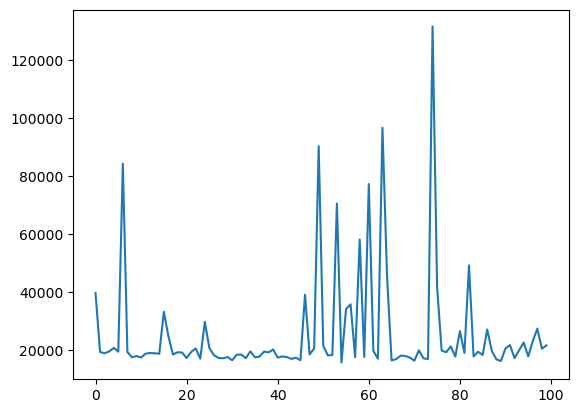

In [8]:
# plt.plot(cart_pole_episode_return['RS_mid_QRNN'])
plt.plot(episode_return_list)

Save dicts


- If the pickles don't exist

In [ ]:
import pickle
with open('cartpole_x_dict.pkl', 'wb') as f:
    pickle.dump(cartpole_x_dict, f)

with open('cartpole_theta_dict.pkl', 'wb') as f:
    pickle.dump(cartpole_theta_dict, f)
    
with open('cartpole_x_dot_dict.pkl', 'wb') as f:
    pickle.dump(cartpole_x_dot_dict, f)

with open('cartpole_theta_dot_dict.pkl', 'wb') as f:
    pickle.dump(cartpole_theta_dot_dict, f)


#####################################

with open('cartpole_x_dict_auc_mean.pkl', 'wb') as f:
    pickle.dump(cartpole_x_dict_auc_mean, f)
    
with open('cartpole_x_dict_auc_std.pkl', 'wb') as f:
    pickle.dump(cartpole_x_dict_auc_std, f)

with open('cartpole_theta_dict_auc_mean.pkl', 'wb') as f:
    pickle.dump(cartpole_theta_dict_auc_mean, f)

with open('cartpole_theta_dict_auc_std.pkl', 'wb') as f:
    pickle.dump(cartpole_theta_dict_auc_std, f)

with open('cartpole_x_dot_dict_auc_mean.pkl', 'wb') as f:
    pickle.dump(cartpole_x_dot_dict_auc_mean, f)

with open('cartpole_x_dot_dict_auc_std.pkl', 'wb') as f:
    pickle.dump(cartpole_x_dot_dict_auc_std, f)

with open('cartpole_theta_dot_dict_auc_mean.pkl', 'wb') as f:
    pickle.dump(cartpole_theta_dot_dict_auc_mean, f)

with open('cartpole_theta_dot_dict_auc_std.pkl', 'wb') as f:
    pickle.dump(cartpole_theta_dot_dict_auc_std, f)

- If the pickles exist


In [ ]:
import pickle
with open('pendulum_theta_dict.pkl', 'wb') as f:
    pickle.dump(pendulum_theta_dict, f)
    
with open('pendulum_theta_dot_dict.pkl', 'wb') as f:
    pickle.dump(pendulum_theta_dot_dict, f)
    
with open('pendulum_theta_dict_auc_mean.pkl', 'wb') as f:
    pickle.dump(pendulum_theta_dict_auc_mean, f)
    
with open('pendulum_theta_dict_auc_std.pkl', 'wb') as f:
    pickle.dump(pendulum_theta_dict_auc_std, f)
    
with open('pendulum_theta_dot_dict_auc_mean.pkl', 'wb') as f:
    pickle.dump(pendulum_theta_dot_dict_auc_mean, f)
    
with open('pendulum_theta_dot_dict_auc_std.pkl', 'wb') as f:
    pickle.dump(pendulum_theta_dot_dict_auc_std, f)

In [ ]:


pendulum_theta_dict = {}
pendulum_theta_dot_dict = {}

pendulum_theta_dict_auc_mean = {}
pendulum_theta_dict_auc_std = {}
pendulum_theta_dot_dict_auc_mean = {}
pendulum_theta_dot_dict_auc_std = {}

Simulation settings


In [ ]:
delta_t = 0.05 # [sec]
sim_steps = 150 # [steps]
print(f"[INFO] delta_t : {delta_t:.2f}[s] , sim_steps : {sim_steps}[steps], total_sim_time : {delta_t*sim_steps:.2f}[s]")

# initialize a pendulum as a control target
pendulum = Pendulum(
    mass_of_pole = 1.0,
    length_of_pole = 1.0,
    max_torque_abs = 2.0,
    max_speed_abs = 8.0,
    delta_t = delta_t,
    visualize = True,
)
pendulum.reset(
    init_state = np.array([np.pi, 0.0]), # [theta(rad), theta_dot(rad/s)]
)

num_quantiles = 11
state_dim = len(pendulum.state)
goal_state_dim = state_dim
action_dim = 1

if use_QRNN:
    
    model_state = NextStateQuantileNetwork(state_dim, action_dim, num_quantiles)
    # optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
    # optimizer_state = optimizer_QRNN
    loss_state = quantile_loss
    # replay_buffer_state = replay_buffer_QRNN

elif use_50NN:
    model_state = NextStateSinglePredNetwork(state_dim, action_dim)
    # optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
    # optimizer_state = optimizer_50NN
    loss_state = quantile_loss_median
    # replay_buffer_state = replay_buffer_50NN

elif use_MSENN:
    model_state = NextStateSinglePredNetwork(state_dim, action_dim)
    # optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
    # optimizer_state = optimizer_MSENN
    loss_state = mse_loss
    # replay_buffer_state = replay_buffer_MSENN

optimizer_state = optim.Adam(model_state.parameters(), lr=1e-3)
replay_buffer_state = [] # Experience replay buffer

if use_ASNN:
    replay_buffer_ASNN = ReplayBuffer_ASNN(10000)
    model_ASNN = ActionSequenceNN(state_dim, goal_state_dim, action_dim)
    optimizer_ASNN = optim.Adam(model_ASNN.parameters(), lr=1e-3)

else:
    replay_buffer_ASNN = None
    model_ASNN = None
    optimizer_ASNN = None


### What to run for a single episode


In [ ]:
prob = "Pendulum_TrueMPC"

# Run Random shooting (RS)
# do_RS = True
# use_ASNN = False
# use_sampling = False
# use_mid = True
# do_QRNN_step_rnd = False
# method_name = "RS_mid_50NN"
# use_QRNN = False
# use_50NN = True
# use_MSENN = False

# use_CEM = False # Use PF
# use_PF = True # Use CEM



# model_50NN = NextStateSinglePredNetwork(state_dim, action_dim)
# optimizer_50NN = optim.Adam(model_50NN.parameters(), lr=1e-3)
# loss_50NN = quantile_loss_median

# # Experience replay buffer
# replay_buffer_50NN = []



time_horizon = 20

batch_size = 32
nb_MPC_iters = 5
num_particles = 100
# stage_cost_weight = np.array([1.0, 0.1]), # weight for [theta, theta_dot]
# terminal_cost_weight = 5.0 * np.array([1.0, 0.1]), # weight for [theta, theta_dot]
stage_cost_weight = torch.tensor([1.0, 0.1]) # weight for [theta, theta_dot]
terminal_cost_weight = 5.0 * torch.tensor([1.0, 0.1]) # weight for [theta, theta_dot]

prob_name = "Pendulum"

# loss_ASNN = None

prob_vars = setup_class(pendulum, prob_name, delta_t, sim_steps, stage_cost_weight, terminal_cost_weight, do_RS, use_sampling, use_mid, use_QRNN, use_50NN, use_MSENN, model_state, optimizer_state, loss_state, replay_buffer_state, use_ASNN, model_ASNN, loss_ASNN, replay_buffer_ASNN, use_CEM, num_quantiles)

# mppi = MPPIControllerForPendulum(
#     delta_t = delta_t,
#     mass_of_pole = 1.0,
#     length_of_pole = 1.0,
#     max_torque_abs = 2.0,
#     max_speed_abs = 8.0,
#     horizon_step_T = 20,
#     number_of_samples_K = 2000,
#     param_exploration = 0.05,
#     param_lambda = 0.5,
#     param_alpha = 0.8,
#     sigma = 1.0,
#     stage_cost_weight    = np.array([1.0, 0.1]), # weight for [theta, theta_dot]
#     terminal_cost_weight = 5.0 * np.array([1.0, 0.1]), # weight for [theta, theta_dot]
# )

# Generate new uniformly random action sequences at each step in the env
particles = generate_random_action_sequences(prob_vars)
print("particles ", particles.shape, "\n")

theta = []
theta_dot = []

# simulation loop
for i in range(sim_steps):

    # get current state of pendulum
    current_state = pendulum.get_state()
    theta.append(current_state[0])
    theta_dot.append(current_state[1])

    # calculate input force with MPPI
    # input_torque, input_torque_sequence = mppi.calc_control_input(
    #     observed_x = current_state
    # )

    if use_QRNN:
        input_torque, input_torque_sequence, best_cost, particles = choose_action_func_QRNN(prob_vars, current_state, particles)

    if use_50NN or use_MSENN:
        input_torque, input_torque_sequence, best_cost, particles = choose_action_func_50NN_MSENN(prob_vars, current_state, particles)

    # print current state and input torque
    print("current_state ", current_state, "\n")
    print("input_torque ", input_torque, "\n")
    print(f"Time: {i*delta_t:>2.2f}[s], theta={current_state[0]:>+3.3f}[rad], theta_dot={current_state[1]:>+3.3f}[rad/s], input torque={input_torque:>+3.2f}[Nm]", end="")
    print(", # currently staying upright #" if abs(current_state[0]) < 0.1 and abs(current_state[1] < 0.1) else "")

    # update states of pendulum
    pendulum.update(u=[input_torque], delta_t=delta_t)

    next_state = pendulum.get_state()

    # replay_buffer_50NN.append((current_state, np.array([input_torque]), next_state))
    replay_buffer_state.append((current_state, np.array([input_torque]), next_state))

    # replay_buffer_ASNN.push(current_state, goal_state, np.array([input_torque]))
    
    if len(replay_buffer_state) < batch_size:
        pass
    else:
        if use_QRNN:
            train_QRNN(prob_vars, prob_vars.model_state, prob_vars.replay_buffer_state, prob_vars.optimizer_state)
        
        if use_50NN or use_MSENN:
            train_50NN_MSENN(prob_vars, prob_vars.model_state, prob_vars.replay_buffer_state, prob_vars.optimizer_state, prob_vars.loss_state)

    if not do_RS or not do_QRNN_step_rnd: # basic method: Shift particles to the left and add new actions sampled for a uniform distribution
                
        particles = ShiftParticlesReplaceWithRandom_func(prob_vars, particles)
                
    particles = np.clip(particles, -pendulum.max_torque, pendulum.max_torque)
    

# show animation
pendulum.show_animation(interval_ms=int(delta_t * 1000))
# save animation
# pendulum.save_animation(f"{method_name}_{prob_name}.mp4", interval=int(delta_t * 1000))
# pendulum.save_animation("mppi_pendulum.mp4", interval=int(delta_t * 1000), movie_writer="ffmpeg") # ffmpeg is required to write mp4 file


In [ ]:
def compute_auc_and_std(data, nb_episodes):
    # data = np.load(filepath, allow_pickle=True)
    # all_returns = data['episode_rewards']  # shape: (n_seeds, n_episodes)
    # print("all_returns ", all_returns, "\n")
    
    # print("all_returns shape:", all_returns.shape, "\n")
    # aucs = []
    # for rewards in all_returns:
    #     returns = rewards[:nb_episodes]
    #     x = np.arange(len(returns))
    #     aucs.append(auc(x, returns))
    
    x = np.arange(len(data))
    aucs = auc(x,data)

    auc_mean = np.mean(aucs)
    auc_std = np.std(aucs)
    return auc_mean, auc_std

pendulum_theta_dict_auc_mean = {}
pendulum_theta_dict_auc_std = {}
pendulum_theta_dot_dict_auc_mean = {}
pendulum_theta_dot_dict_auc_std = {}

auc_theta_mean, auc_theta_std = compute_auc_and_std(theta, sim_steps)
auc_theta_dot_mean, auc_theta_dot_std = compute_auc_and_std(theta_dot, sim_steps)

print(f"{method_name} - theta: AUC = {auc_theta_mean:.2f} ± {auc_theta_std:.2f} \n")
print(f"{method_name} - theta_dot: AUC = {auc_theta_dot_mean:.2f} ± {auc_theta_dot_std:.2f} \n")

# print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f}")
# pendulum_theta_dict_auc_mean[label] = auc_mean
# pendulum_theta_dict_auc_std[label] = auc_std

    

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
plt.plot(np.arange(0, sim_steps*delta_t, delta_t), np.rad2deg(theta), label="theta [deg]")
plt.xlabel("time [s]")
plt.ylabel("angle [deg]")
plt.legend()

In [ ]:
plt.plot(np.arange(0, sim_steps*delta_t, delta_t), np.rad2deg(theta_dot), label="theta_dot [deg/s]")
plt.xlabel("time [s]")
plt.ylabel("angular velocity [deg/s]")
# plt.legend()


In [ ]:
plt.plot()

Working code


In [ ]:
# simulation settings
delta_t = 0.05 # [sec]
sim_steps = 150 # [steps]
print(f"[INFO] delta_t : {delta_t:.2f}[s] , sim_steps : {sim_steps}[steps], total_sim_time : {delta_t*sim_steps:.2f}[s]")

# initialize a pendulum as a control target
pendulum = Pendulum(
    mass_of_pole = 1.0,
    length_of_pole = 1.0,
    max_torque_abs = 2.0,
    max_speed_abs = 8.0,
    delta_t = delta_t,
    visualize = True,
)
pendulum.reset(
    init_state = np.array([np.pi, 0.0]), # [theta(rad), theta_dot(rad/s)]
)

prob = "Pendulum_TrueMPC"

# Run Random shooting (RS)
do_RS = True
use_ASNN = False
use_sampling = False
use_mid = True
do_QRNN_step_rnd = False
method_name = "RS_mid_50NN"
use_QRNN = False
use_50NN = True
use_MSENN = False

use_CEM = False # Use PF
# use_PF = True # Use CEM

state_dim = len(pendulum.state)
action_dim = 1

model_50NN = NextStateSinglePredNetwork(state_dim, action_dim)
optimizer_50NN = optim.Adam(model_50NN.parameters(), lr=1e-3)
loss_50NN = quantile_loss_median

# Experience replay buffer
replay_buffer_50NN = []

replay_buffer_ASNN = None
model_ASNN = None
optimizer_ASNN = None

time_horizon = 20

batch_size = 32
nb_MPC_iters = 5
num_particles = 100
# stage_cost_weight = np.array([1.0, 0.1]), # weight for [theta, theta_dot]
# terminal_cost_weight = 5.0 * np.array([1.0, 0.1]), # weight for [theta, theta_dot]
stage_cost_weight = torch.tensor([1.0, 0.1]) # weight for [theta, theta_dot]
terminal_cost_weight = 5.0 * torch.tensor([1.0, 0.1]) # weight for [theta, theta_dot]

prob_name = "Pendulum"

loss_ASNN = None

prob_vars = setup_class(pendulum, prob_name, delta_t, sim_steps, stage_cost_weight, terminal_cost_weight, do_RS, use_sampling, use_mid, use_QRNN, use_50NN, use_MSENN, model_50NN, optimizer_50NN, loss_50NN, replay_buffer_50NN, use_ASNN, model_ASNN, loss_ASNN, replay_buffer_ASNN, use_CEM)

# mppi = MPPIControllerForPendulum(
#     delta_t = delta_t,
#     mass_of_pole = 1.0,
#     length_of_pole = 1.0,
#     max_torque_abs = 2.0,
#     max_speed_abs = 8.0,
#     horizon_step_T = 20,
#     number_of_samples_K = 2000,
#     param_exploration = 0.05,
#     param_lambda = 0.5,
#     param_alpha = 0.8,
#     sigma = 1.0,
#     stage_cost_weight    = np.array([1.0, 0.1]), # weight for [theta, theta_dot]
#     terminal_cost_weight = 5.0 * np.array([1.0, 0.1]), # weight for [theta, theta_dot]
# )

# Generate new uniformly random action sequences at each step in the env
particles = generate_random_action_sequences(prob_vars)
print("particles ", particles.shape, "\n")

theta = []
theta_dot = []

# simulation loop
for i in range(sim_steps):

    # get current state of pendulum
    current_state = pendulum.get_state()
    theta.append(current_state[0])
    theta_dot.append(current_state[1])

    # calculate input force with MPPI
    # input_torque, input_torque_sequence = mppi.calc_control_input(
    #     observed_x = current_state
    # )

    input_torque, input_torque_sequence, best_cost, particles = choose_action_func_50NN_MSENN(prob_vars, current_state, particles)

    # print current state and input torque
    print(f"Time: {i*delta_t:>2.2f}[s], theta={current_state[0]:>+3.3f}[rad], theta_dot={current_state[1]:>+3.3f}[rad/s], input torque={input_torque:>+3.2f}[Nm]", end="")
    print(", # currently staying upright #" if abs(current_state[0]) < 0.1 and abs(current_state[1] < 0.1) else "")

    # update states of pendulum
    pendulum.update(u=[input_torque], delta_t=delta_t)

    next_state = pendulum.get_state()

    replay_buffer_50NN.append((current_state, np.array([input_torque]), next_state))
    # replay_buffer_ASNN.push(current_state, goal_state, np.array([input_torque]))
    
    if len(replay_buffer_50NN) < batch_size:
        pass
    else:
        train_50NN_MSENN(prob_vars, prob_vars.model_state, prob_vars.replay_buffer_state, prob_vars.optimizer_state, prob_vars.loss_state)

    if not do_RS or not do_QRNN_step_rnd: # basic method: Shift particles to the left and add new actions sampled for a uniform distribution
                
        particles = ShiftParticlesReplaceWithRandom_func(prob_vars, particles)
                
    particles = np.clip(particles, -pendulum.max_torque, pendulum.max_torque)
    

# show animation
pendulum.show_animation(interval_ms=int(delta_t * 1000))
# save animation
# pendulum.save_animation(f"{method_name}_{prob_name}.mp4", interval=int(delta_t * 1000))
# pendulum.save_animation("mppi_pendulum.mp4", interval=int(delta_t * 1000), movie_writer="ffmpeg") # ffmpeg is required to write mp4 file

In [ ]:
pendulum_theta_dict_auc_mean = {}
pendulum_theta_dict_auc_std = {}
pendulum_theta_dot_dict_auc_mean = {}
pendulum_theta_dot_dict_auc_std = {}

auc_theta_mean, auc_theta_std = compute_auc_and_std(theta, sim_steps)
auc_theta_dot_mean, auc_theta_dot_std = compute_auc_and_std(theta_dot, sim_steps)

print(f"{method_name} - theta: AUC = {auc_theta_mean:.2f} ± {auc_theta_std:.2f} \n")
print(f"{method_name} - theta_dot: AUC = {auc_theta_dot_mean:.2f} ± {auc_theta_dot_std:.2f} \n")
